# LDA Final Project Notebook
## Completed by William Brannock (svv8fs)

This notebook is used to complete the LDA tasks for the Final Project. I used this class notebook as a guide. https://www.kaggle.com/code/ontoligent/uva-ds-5001-m08-lda-with-sklearn


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, PCA

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_home = "."
output_dir = Path("output")
fig_dir = Path("iframe_figures")
fig_dir.mkdir(exist_ok=True)

data_prefix = "constitutions"
CSV_DELIM = "|"

OHCO = [
    "constitution_id",
    "provision_num",
    "para_num",
    "sent_num",
    "token_num",
]

bags = dict(
    SENTS=OHCO[:4],
    PARAS=OHCO[:3],
    PROVISIONS=OHCO[:2],
    CONSTITUTIONS=OHCO[:1],
)

bag = "CONSTITUTIONS"
BAG = bags[bag]

n_topics = 5
max_iter = 100
n_top_terms = 10
random_state = 42
TNAMES = [f"T{x:02d}" for x in range(n_topics)]

## Load Tables

The source tables come from the earlier project notebooks and use the same pipe delimiter as the rest of the final project output.


In [3]:
LIB = pd.read_csv(
    output_dir / f"{data_prefix}-LIB.csv",
    sep=CSV_DELIM,
    keep_default_na=False,
).set_index("constitution_id")

TOKEN = pd.read_csv(
    output_dir / f"{data_prefix}-CORPUS.csv",
    sep=CSV_DELIM,
    keep_default_na=False,
).set_index(OHCO)

VOCAB_SOURCE = pd.read_csv(
    output_dir / f"{data_prefix}-VOCAB.csv",
    sep=CSV_DELIM,
    keep_default_na=False,
).set_index("term_str")

LIB.head()

,source_file_path,country,file_year,title,original_year,revision_year,provision_regex,constitution_len,n_provisions,n_chars
constitution_id,,,,,,,,,,
Afghanistan_2004,./data/Afghanistan_2004.txt,Afghanistan,2004,Afghanistan,2004.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,10435,175,66806
Albania_2008,./data/Albania_2008.txt,Albania,2008,Albania,1998.0,2008,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,13896,623,86022
Algeria_2008,./data/Algeria_2008.txt,Algeria,2008,Algeria,1963.0,2008,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,10605,197,66590
Andorra_1993,./data/Andorra_1993.txt,Andorra,1993,Andorra,1993.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,8722,295,55687
Angola_2010,./data/Angola_2010.txt,Angola,2010,Angola,2010.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,26657,856,175148


## Build LDA Documents

My Filtering choices:

- Keep nouns and verbs only aka `pos_group` in `NN`, `VB`
- Drop terms already marked as stopwords in VOCAB
- Drop terms shorter than three characters.
- Add a few corpus-structure words to sklearn's English stopword list.


In [4]:
TOKEN = TOKEN.dropna(subset=["term_str"]).copy()
TOKEN = TOKEN.loc[TOKEN.term_str.astype(str).str.len() > 0]
TOKEN["term_str"] = TOKEN.term_str.astype(str)
TOKEN["pos_group"] = TOKEN.pos_group.astype(str)

VOCAB_SOURCE["stop"] = pd.to_numeric(VOCAB_SOURCE["stop"], errors="coerce").fillna(0).astype(int)
VOCAB_SOURCE["n_chars"] = pd.to_numeric(VOCAB_SOURCE["n_chars"], errors="coerce").fillna(0).astype(int)
valid_terms = VOCAB_SOURCE[(VOCAB_SOURCE.stop == 0) & (VOCAB_SOURCE.n_chars >= 3)].index

lda_tokens = TOKEN[
    TOKEN.pos_group.isin(["NN", "VB"])
    & TOKEN.term_str.isin(valid_terms)
].copy()

DOCS = lda_tokens.groupby(BAG).term_str.apply(lambda x: " ".join(map(str, x))).to_frame("doc_str")
DOCS = DOCS.reindex(LIB.index).fillna({"doc_str": ""})
DOCS.head()

,doc_str
constitution_id,
Afghanistan_2004,name allah beneficent merciful praise allah ch...
Albania_2008,people albania proud aware history responsibil...
Algeria_2008,people people decided remain history chain bat...
Andorra_1993,andorran people liberty independence exercise ...
Angola_2010,people angola representatives legislators nati...


In [5]:
my_stop_words = sorted(text.ENGLISH_STOP_WORDS.union({
    "shall",
    "may",
    "article",
    "section",
    "chapter",
    "part",
    "constitution",
    "law",
    "laws",
    "act",
    "acts",
}))

count_engine = CountVectorizer(
    max_df=.9,
    min_df=5,
    stop_words=my_stop_words,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
)

count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()

DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM.index.name = "constitution_id"
DTM.shape

(192, 6564)

## Generate LDA Model


In [6]:
topic_engine = LDA(
    n_components=n_topics,
    max_iter=max_iter,
    learning_method="batch",
    random_state=random_state,
)

topic_model = topic_engine.fit_transform(count_model)

THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.index.name = "constitution_id"
THETA.columns.name = "topic_id"

PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = "topic_id"
PHI.columns.name = "term_str"

THETA.head()

topic_id,T00,T01,T02,T03,T04
constitution_id,,,,,
Afghanistan_2004,0.000094,0.134856,0.542237,0.051067,0.271746
Albania_2008,0.000071,0.021438,0.280351,0.000071,0.698069
Algeria_2008,0.000089,0.000089,0.185952,0.000089,0.813782
Andorra_1993,0.060263,0.234235,0.256412,0.000114,0.448976
Angola_2010,0.000033,0.214982,0.375419,0.000033,0.409533


In [7]:
PHI.shape

(5, 6564)

## Create `TOPIC` Table

This follows the class example by printing each topic with its top words. The `TOPIC` table keeps the same information for the CSV deliverable.


In [16]:
topic_rows = []

for topic_id, weights in zip(TNAMES, topic_engine.components_):
    top_indices = weights.argsort()[::-1][:n_top_terms]
    top_words = TERMS[top_indices]
    print(f"{topic_id}: {' '.join(top_words)}")
    

T00: parliament commission subsection house governor speaker appeal prime acting proceedings provision purpose
T01: congress services federal national tribunal states art district entities vice iii regulate
T02: national parliament federal house committee art legislation paragraph ensure bodies federation land
T03: parliament clause commission union chief list legislature house speaker province region schedule
T04: republic national constitutional deputies prime parliament organization chamber territory specified guaranteed freedoms


## LDA THETA Deliverable

- UVA Box URL: add after uploading `output/constitutions-LDA_THETA-CONSTITUTIONS.csv`
- GitHub URL for notebook used to create: `LDA_FinalProject.ipynb`
- Delimitter: `|`

`THETA` has one row per constitution and one column per topic. Each row sums to 1, so each value is the estimated topic weight for that constitution.


In [9]:
THETA.head()

topic_id,T00,T01,T02,T03,T04
constitution_id,,,,,
Afghanistan_2004,0.000094,0.134856,0.542237,0.051067,0.271746
Albania_2008,0.000071,0.021438,0.280351,0.000071,0.698069
Algeria_2008,0.000089,0.000089,0.185952,0.000089,0.813782
Andorra_1993,0.060263,0.234235,0.256412,0.000114,0.448976
Angola_2010,0.000033,0.214982,0.375419,0.000033,0.409533


In [10]:
THETA.sum(axis=1).describe()

count    1.920000e+02
mean     1.000000e+00
std      9.124066e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

## LDA PHI Deliverable

- UVA Box URL: add after uploading `output/constitutions-LDA_PHI-CONSTITUTIONS.csv`
- GitHub URL for notebook used to create: `LDA_FinalProject.ipynb`
- Delimitter: `|`

`PHI` has one row per topic and one column per term. Each value is sklearn's learned topic-term component weight.


In [11]:
PHI.iloc[:, :20]

term_str,abandon,abandoned,abandonment,abdicate,abdication,abets,abeyance,abide,abiding,abilities,ability,abolish,abolished,abolishes,abolishing,abolition,abridge,abridged,abridges,abroad
topic_id,,,,,,,,,,,,,,,,,,,,
T00,0.200083,3.873785,2.430201,4.947025,4.874364,2.983720,0.200340,0.206495,1.217713,0.201737,25.971774,26.260597,36.225566,0.205387,7.341190,20.369549,12.131626,12.511626,0.214766,0.200095
T01,0.214387,18.996377,0.214813,0.200696,0.200397,0.200311,0.200122,0.212885,0.212037,0.205370,12.494112,11.486869,19.415479,0.200324,1.598715,19.142204,0.202255,0.204255,0.208490,0.207039
T02,3.720654,14.716271,2.152291,0.205481,9.512173,0.202766,37.195869,72.737982,12.165032,27.828986,97.635265,18.091819,29.663163,7.181047,0.213263,24.352175,0.202994,0.201663,0.215311,0.203660
T03,0.204570,0.208948,1.951899,1.446126,0.212224,3.412861,0.203400,7.643598,0.200027,0.202786,49.693451,3.953832,11.669232,0.208560,5.499358,74.889213,0.212794,12.797602,7.800479,0.200246
T04,6.660306,0.204619,33.250795,0.200672,0.200842,0.200342,0.200269,16.199040,0.205192,24.561121,0.205398,0.206883,6.026561,0.204681,6.347474,3.246860,1.250331,1.284853,2.560954,8.188960


## LDA + PCA Visualization

Apply PCA to the `THETA` table and plot documents in the space opened by the first two components. Point size is based on the mean document weight of each document's dominant topic, and color is based on the `original_year` metadata field from `LIB`.


In [12]:
THETAX = THETA.join(LIB, how="left")
THETAX["dominant_topic"] = THETA.idxmax(axis=1)
THETAX["dominant_topic_weight"] = THETA.max(axis=1)
THETAX["dominant_topic_mean_weight"] = THETAX.dominant_topic.map(TOPIC.doc_weight_mean)

pca_engine = PCA(n_components=2, random_state=random_state)
TPC = pd.DataFrame(pca_engine.fit_transform(THETA), index=THETA.index, columns=["PC0", "PC1"])
TPC.index.name = "constitution_id"
TPC = TPC.join(THETAX[[
    "country",
    "file_year",
    "original_year",
    "n_chars",
    "dominant_topic",
    "dominant_topic_weight",
    "dominant_topic_mean_weight",
]])

TPC.head()

,PC0,PC1,country,file_year,original_year,n_chars,dominant_topic,dominant_topic_weight,dominant_topic_mean_weight
constitution_id,,,,,,,,,
Afghanistan_2004,-0.154103,0.274595,Afghanistan,2004,2004.0,66806,T02,0.542237,0.290390
Albania_2008,-0.385675,-0.169433,Albania,2008,1998.0,86022,T04,0.698069,0.313876
Algeria_2008,-0.443736,-0.306394,Algeria,2008,1963.0,66590,T04,0.813782,0.313876
Andorra_1993,-0.191601,-0.059656,Andorra,1993,1993.0,55687,T04,0.448976,0.313876
Angola_2010,-0.228088,0.071641,Angola,2010,2010.0,175148,T04,0.409533,0.313876


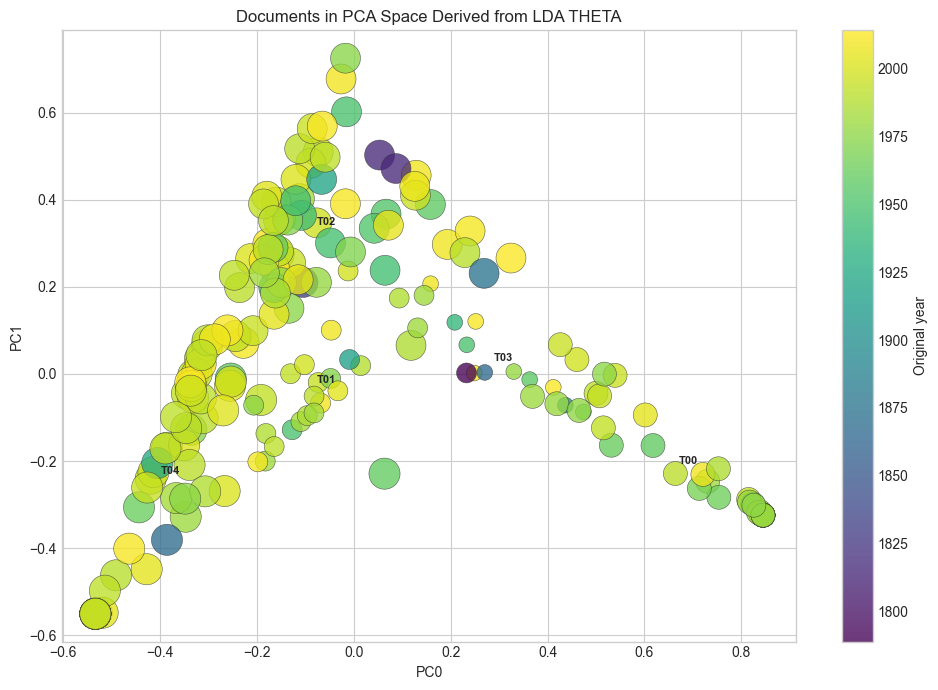

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
year = pd.to_numeric(TPC["original_year"], errors="coerce").fillna(pd.to_numeric(TPC["file_year"], errors="coerce"))
sizes = 1600 * TPC.dominant_topic_mean_weight
sc = ax.scatter(
    TPC.PC0,
    TPC.PC1,
    c=year,
    s=sizes,
    alpha=.78,
    cmap="viridis",
    edgecolor="#333333",
    linewidth=.4,
)
for topic_id, group in TPC.groupby("dominant_topic"):
    centroid = group[["PC0", "PC1"]].mean()
    ax.text(centroid.PC0, centroid.PC1, topic_id, weight="bold", fontsize=8, ha="center")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Original year")
ax.set_title("Documents in PCA Space Derived from LDA THETA")
ax.set_xlabel("PC0")
ax.set_ylabel("PC1")
fig.tight_layout()
fig.savefig(fig_dir / "lda_theta_pca.png", dpi=180, bbox_inches="tight")

![](iframe_figures/lda_theta_pca.png)

Interpretation: the PCA projection of `THETA` mainly separates constitutions by their dominant topic mixture rather than by a clean chronological gradient. Documents with strong weights on the larger state-administration and rights/legal topics cluster toward the central mass, while smaller topic mixtures form lighter edge groups. The year color is mixed across the plot, suggesting that topic structure in this constitution corpus is not explained by original year alone.


## Save LDA Outputs

The files below are the LDA deliverable tables plus the count matrix requested with the LDA topic deliverable.


In [14]:
save_path = output_dir / data_prefix

saved_files = [
    output_dir / f"{data_prefix}-LDA_DTM-{bag}.csv",
    output_dir / f"{data_prefix}-LDA_TOPIC-{bag}.csv",
    output_dir / f"{data_prefix}-LDA_THETA-{bag}.csv",
    output_dir / f"{data_prefix}-LDA_PHI-{bag}.csv",
]

DTM.to_csv(saved_files[0], sep=CSV_DELIM)
TOPIC.to_csv(saved_files[1], sep=CSV_DELIM)
THETA.to_csv(saved_files[2], sep=CSV_DELIM)
PHI.to_csv(saved_files[3], sep=CSV_DELIM)

saved_files

[PosixPath('output/constitutions-LDA_DTM-CONSTITUTIONS.csv'),
 PosixPath('output/constitutions-LDA_TOPIC-CONSTITUTIONS.csv'),
 PosixPath('output/constitutions-LDA_THETA-CONSTITUTIONS.csv'),
 PosixPath('output/constitutions-LDA_PHI-CONSTITUTIONS.csv')]